# Antineutrinos, done properly

Going from neutrinos to antineutrinos changes **two** things in the Hamiltonian, and
they are easy to get half right:

1. the PMNS matrix is **conjugated**, $\mathbf{U} \to \mathbf{U}^*$, which flips the sign of
   the CP phase $\delta_{\rm CP}$; and
2. the matter potential **changes sign**, $V_{\rm CC} \to -V_{\rm CC}$, because the coherent
   forward scattering of $\bar\nu_e$ off electrons has the opposite sign.

Apply one and not the other and nothing complains. The result is still a valid, doubly
stochastic probability matrix, still between zero and one, still of the right general shape --
it is simply the answer to a different question. This is the single most defect-prone
convention in the package: at one point the sign was applied **twice** inside Mag$\nu$s
itself, which gave antineutrinos a *positive* matter potential and plausible-looking wrong
answers throughout.

In ordinary use you never do either by hand. Every wrapper takes `nubar=True` and does both:

```python
oscprob.osc_prob_3nu_matter_constant_density(energy, L, rho, **osc, nubar=True)
```

This notebook takes the flag apart to show what it stands for, what the two half-right
constructions look like, and which identities have to hold if you got it right.

In [1]:
# The figures are set through LaTeX where one is available; where it is not,
# matplotlib's own mathtext renders the labels instead.  Same numbers either way.
import shutil

import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = shutil.which('latex') is not None

In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Mag(nu)s is imported as an installed package -- from the repository root,
# 'pip install -e .' (add [plot] for magnus.plotting). No sys.path juggling.
import magnus.oscprob as oscprob
import magnus.hamiltonians as hamiltonians
import magnus.matter as matter
import magnus.earth as earth
import magnus.globaldefs as gd
import magnus.plotting as plotting

## 1. The rule, taken apart

We work at a long-baseline configuration -- 1300 km through the crust, the DUNE baseline --
in the $\nu_\mu \to \nu_e$ appearance channel, where the CP phase and the matter effect both
matter and neither dominates.

In [3]:
# load_nufit_params returns exactly the six mixing parameters, ready to splat
# into any osc_prob_3nu_* call.  'NuFIT 6.1' is the package default.
OSC = gd.load_nufit_params('NuFIT 6.1', 'NO')
osc = OSC

RHO = 2.848                                   # Earth's crust [g cm^-3]
energy = 2.0*gd.UNIT_GEV                      # [eV]
baseline = 1300.0*gd.UNIT_KM                  # [eV^-1]

for name, value in OSC.items():
    print('%-5s = %+.5e' % (name, value))

s12   = +5.55698e-01
s23   = +6.85565e-01
s13   = +1.49933e-01
dCP   = +3.70010e+00
D21   = +7.53700e-05
D31   = +2.51100e-03


Now build the Hamiltonian with the two flips under separate control. `nubar` appears
twice below, and they are *different* arguments -- one on the vacuum term, one on the
potential:

$$\mathbf{H} = \frac{1}{2E}\,\mathbf{U}\,\mathbf{M}^2\,\mathbf{U}^\dagger
             \;+\; {\rm diag}(V_{\rm CC}, 0, 0)$$

In [4]:
def prob_halves(conjugate_pmns, flip_potential, energy=energy, L=baseline):
    """P for a Hamiltonian with each half of the antineutrino rule applied, or not.

    conjugate_pmns -> U becomes U*, flipping the sign of dCP
    flip_potential -> V_CC becomes -V_CC
    Both True is the antineutrino; both False is the neutrino."""
    h_vac = hamiltonians.hamiltonian_3nu_vacuum_energy_independent(
        **OSC, nubar=conjugate_pmns)                       # [eV^2]
    vcc = matter.vcc_func_from_rho_func(
        RHO, nubar=flip_potential, density_matter_is_in_g_per_cm3=True)   # [eV]
    H = np.asarray(h_vac)/energy + np.diag([vcc, 0.0, 0.0])
    return oscprob.osc_prob(H, 0.0, L)

## 2. Two ways to get it half right

All four numbers below are unremarkable probabilities. Nothing about the two middle rows
looks wrong -- that is the entire problem.

In [5]:
print('%-28s %s' % ('construction', 'P(nu_mu -> nu_e)'))
print('-'*48)
for name, conj, flip in [('neutrino',                False, False),
                         ('antineutrino (correct)',  True,  True),
                         ('conjugate PMNS only',     True,  False),
                         ('flip potential only',     False, True)]:
    print('%-28s %.6f' % (name, prob_halves(conj, flip)[gd.NUMU][gd.NUE]))

construction                 P(nu_mu -> nu_e)
------------------------------------------------
neutrino                     0.075988
antineutrino (correct)       0.014700
conjugate PMNS only          0.057590
flip potential only          0.023882


Conjugating alone overstates the appearance probability by a factor of four; flipping
the potential alone overstates it by a factor of about 1.6. Both sit between the neutrino and
the antineutrino values, which is exactly where a plausible wrong answer lives.

The hand-built version is not a re-derivation -- it reproduces what the wrapper does, to
every digit, for both signs:

In [6]:
for nubar in (False, True):
    from_wrapper = oscprob.osc_prob_3nu_matter_constant_density(
        energy, baseline, RHO, **OSC, nubar=nubar,
        density_matter_is_in_g_per_cm3=True)[gd.NUMU][gd.NUE]
    by_hand = prob_halves(nubar, nubar)[gd.NUMU][gd.NUE]
    print('nubar=%-6s wrapper %.9f   by hand %.9f   |difference| %.1e'
          % (nubar, from_wrapper, by_hand, abs(from_wrapper - by_hand)))

nubar=False  wrapper 0.075988063   by hand 0.075988063   |difference| 0.0e+00
nubar=True   wrapper 0.014700424   by hand 0.014700424   |difference| 0.0e+00


## 3. Where the sign lives

The antineutrino sign of the potential is applied in exactly **one** place in Mag$\nu$s,
`matter.vcc_func_from_rho_func`, and every entry point routes through it. That is deliberate:
the one bug this convention actually produced was the sign being applied *twice*, once in the
potential builder and once again by the caller, which is only possible when there is more than
one place it could live.

So if you assemble a Hamiltonian yourself, take the potential from that function and do
**not** negate it again:

In [7]:
v_nu = matter.vcc_func_from_rho_func(RHO, density_matter_is_in_g_per_cm3=True)
v_nubar = matter.vcc_func_from_rho_func(RHO, nubar=True,
                                        density_matter_is_in_g_per_cm3=True)
print('V_CC(nu)    = %+.5e eV' % v_nu)
print('V_CC(nubar) = %+.5e eV' % v_nubar)
print('sum         = %+.1e   (they are exact negatives, applied once)'
      % (v_nu + v_nubar))

V_CC(nu)    = +1.07806e-13 eV
V_CC(nubar) = -1.07806e-13 eV
sum         = +0.0e+00   (they are exact negatives, applied once)


## 4. The four constructions against energy

Below the appearance peak the curves are hard to tell apart; through the peak they separate
by more than the CP-violation signal any experiment is trying to measure. A wrong convention
would not look like a bug in a plot like this -- it would look like a different value of
$\delta_{\rm CP}$.

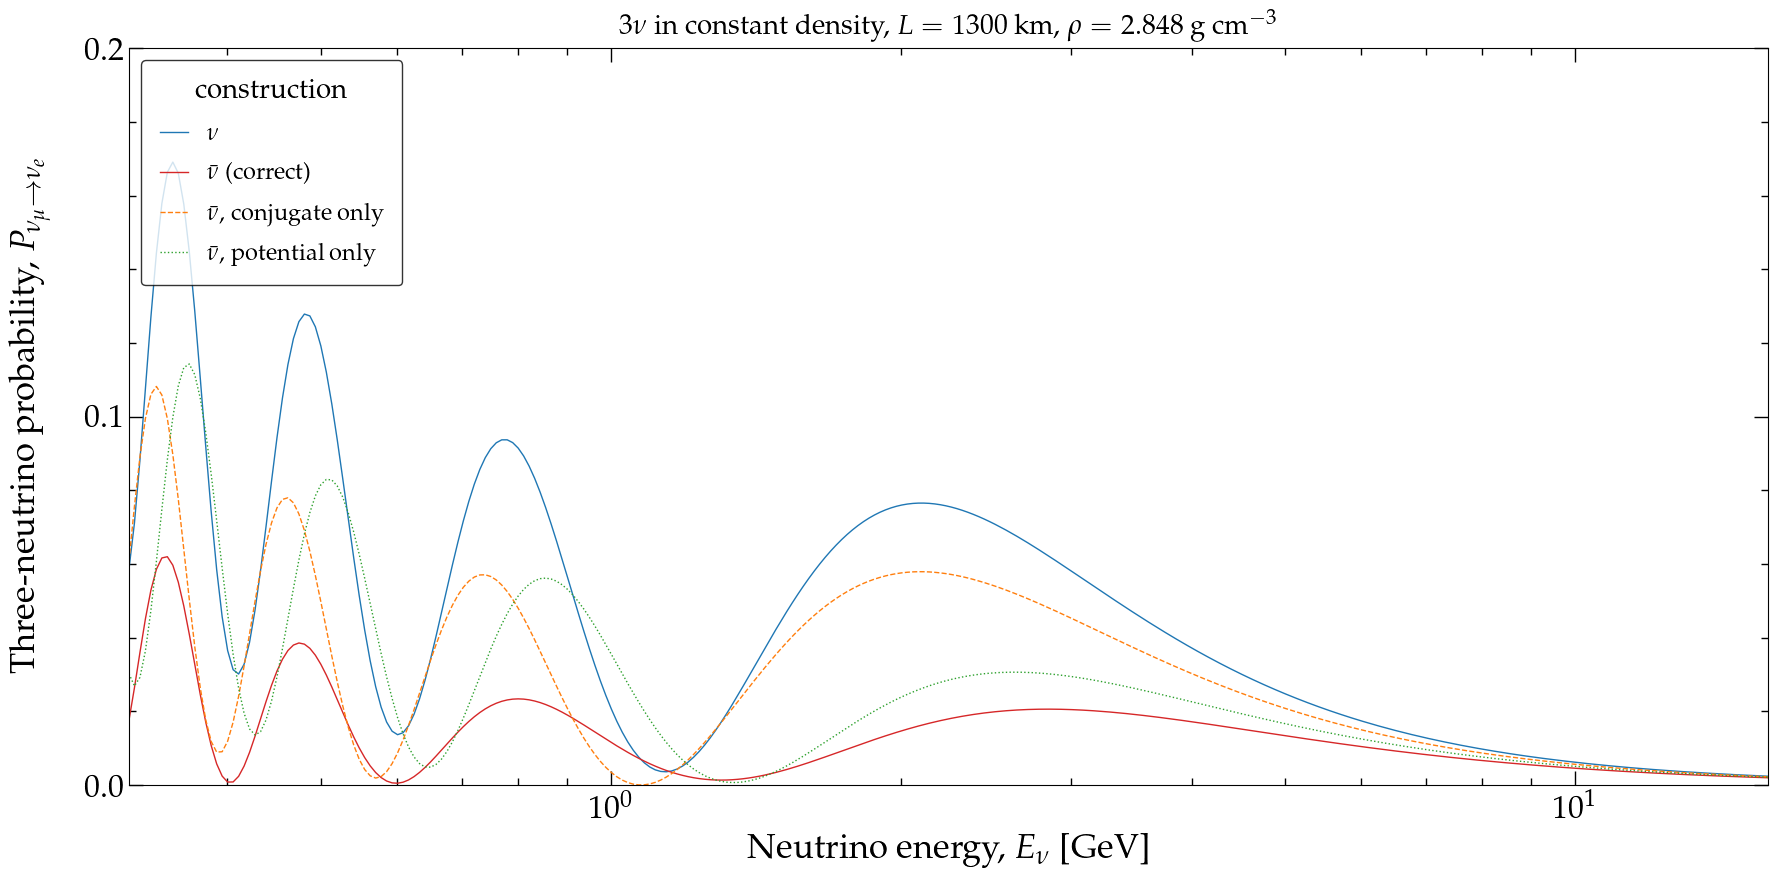

In [8]:
E_gev = np.logspace(-0.5, 1.2, 300)
E = E_gev*gd.UNIT_GEV

def curve(conjugate_pmns, flip_potential):
    h_vac = np.asarray(hamiltonians.hamiltonian_3nu_vacuum_energy_independent(
        **OSC, nubar=conjugate_pmns))
    vcc = matter.vcc_func_from_rho_func(RHO, nubar=flip_potential,
                                        density_matter_is_in_g_per_cm3=True)
    return np.array([oscprob.osc_prob(h_vac/e + np.diag([vcc, 0.0, 0.0]),
                                      0.0, baseline)[gd.NUMU][gd.NUE] for e in E])

specs = [(r'$\nu$',                        False, False, 'C0', '-'),
         (r'$\bar\nu$ (correct)',          True,  True,  'C3', '-'),
         (r'$\bar\nu$, conjugate only',    True,  False, 'C1', '--'),
         (r'$\bar\nu$, potential only',    False, True,  'C2', ':')]
curves = [dict(y=curve(c, f), label=lab, color=col, ls=ls)
          for lab, c, f, col, ls in specs]

fig, ax = plotting.plot_probability_vs_energy(
    E_gev, curves, nu_i=gd.NUMU, nu_f=gd.NUE, num_flavors=3,
    xlim=(E_gev[0], E_gev[-1]), ylim=(0.0, 0.2),
    legend_title='construction', legend_loc='upper left',
    title=(r'$3\nu$ in constant density, $L = 1300$ km, '
           r'$\rho = 2.848$ g cm$^{-3}$'))

## 5. Checks that must hold

Three identities separate a correct antineutrino calculation from a plausible one. They are
worth running whenever you build a Hamiltonian by hand.

**CP: with $\delta_{\rm CP} = 0$ and no matter, neutrinos and antineutrinos are identical.**
Conjugating a real matrix does nothing, so the two must agree to machine precision. If they
do not, the potential is not zero when you think it is.

In [9]:
for dcp in (0.0, np.pi/2):
    Q = dict(OSC, dCP=dcp)
    p = oscprob.osc_prob_3nu_vacuum(energy, baseline, **Q)[gd.NUMU][gd.NUE]
    pbar = oscprob.osc_prob_3nu_vacuum(energy, baseline, **Q,
                                       nubar=True)[gd.NUMU][gd.NUE]
    print('dCP = %.4f   P = %.9f   Pbar = %.9f   |P - Pbar| = %.2e'
          % (dcp, p, pbar, abs(p - pbar)))

dCP = 0.0000   P = 0.027690483   Pbar = 0.027690483   |P - Pbar| = 0.00e+00
dCP = 1.5708   P = 0.020854890   Pbar = 0.047591203   |P - Pbar| = 2.67e-02


**CPT: in vacuum, $P(\nu_\alpha \to \nu_\beta) = P(\bar\nu_\beta \to \bar\nu_\alpha)$
for any $\delta_{\rm CP}$.** Note the reversed flavor indices -- this is the *transpose*, not
the matrix itself. CP is violated here and CPT is not, so the first number below is zero and
the second is not.

In [10]:
Q = dict(OSC, dCP=1.234)
P_nu = np.asarray(oscprob.osc_prob_3nu_vacuum(energy, baseline, **Q))
P_nubar = np.asarray(oscprob.osc_prob_3nu_vacuum(energy, baseline, **Q, nubar=True))

print('vacuum, max |P[a][b] - Pbar[b][a]| = %.2e   <- CPT, must vanish'
      % np.max(np.abs(P_nu - P_nubar.T)))
print('vacuum, max |P[a][b] - Pbar[a][b]| = %.2e   <- CP, need not'
      % np.max(np.abs(P_nu - P_nubar)))

vacuum, max |P[a][b] - Pbar[b][a]| = 0.00e+00   <- CPT, must vanish
vacuum, max |P[a][b] - Pbar[a][b]| = 2.52e-02   <- CP, need not


**In matter, CPT no longer relates the two.** Ordinary matter is made of electrons
and not positrons, so it is a CPT-odd background: the transpose identity is *expected* to
fail, and a calculation in which it still held would be the suspicious one.

In [11]:
P_nu = np.asarray(prob_halves(False, False))
P_nubar = np.asarray(prob_halves(True, True))
print('matter, max |P[a][b] - Pbar[b][a]| = %.2e   <- no longer a symmetry'
      % np.max(np.abs(P_nu - P_nubar.T)))

# Unitarity survives regardless: every row still sums to one.
print('row sums, nubar: %s' % np.round(P_nubar.sum(axis=1), 12))

matter, max |P[a][b] - Pbar[b][a]| = 9.30e-02   <- no longer a symmetry
row sums, nubar: [1. 1. 1.]


## Summary

| | conjugate $\mathbf{U}$ | flip $V_{\rm CC}$ | result |
|---|---|---|---|
| neutrino | no | no | correct |
| **antineutrino** | **yes** | **yes** | **correct** |
| half right | yes | no | plausible, wrong |
| half right | no | yes | plausible, wrong |
| the old bug | yes | *twice* | plausible, wrong |

Both flips, or neither. In practice: **pass `nubar=True` and let the wrapper do it**, and if
you must build the Hamiltonian yourself, take $V_{\rm CC}$ from
`matter.vcc_func_from_rho_func(..., nubar=True)` and never negate it again.

The three checks in section 5 are cheap enough to keep in a test: CP agreement at
$\delta_{\rm CP} = 0$ in vacuum, the CPT transpose identity in vacuum, and its expected
failure in matter.

---

**Previous:** [A supernova shock front](14_magnus_supernova_shock.ipynb)  
**Next:** [Exact versus the approximations](16_magnus_exact_vs_approximations.ipynb) --- where the textbook formulas are exact, and where the substitution breaks  
[API reference](https://mbustama.github.io/Magnus/functions.html) &middot; [Implementation details](https://mbustama.github.io/Magnus/implementation_details.html) &middot; [All notebooks](.)